<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2026-Tutorial-Notebooks/blob/main/exercises/ex1/ex1_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1
## Starting Point for Exercise 1, part II

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part II.

One of the goals of this exercise is to make you acquainted with **skorch**. You will probably need to consult the [documentation](https://skorch.readthedocs.io/en/stable/).

## Use of generative AI

AI tools may be used in this exercise to help you explain code, debug, improve documentation, and explore alternatives. Any use must be documented in the *Declaration on the use of AI* at the end of this notebook (which tools were used and for which purposes). You remain responsible for understanding, checking, and testing everything you submit, and you must be able to explain any submitted text, code, analyses, and AI-assisted contributions. See the [CL guidelines on academic integrity and AI use](https://www.cl.uzh.ch/en/Studies/Services/academic-integrity.html).

# Setup

In [1]:
# Pin the library versions used in this course (the same ones as in Part I and the W04 tutorial).
# PyTorch is preinstalled on Colab; for a local installation see https://pytorch.org/get-started/locally/
%pip install -q scikit-learn==1.9.1 skorch==1.4.0 gdown

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier

import pandas as pd
import numpy as np
import csv
import re
import string
from collections import defaultdict

# Set seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

## Training a classifier and making predictions

In [ ]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

In [4]:
with open('x_train.txt') as f:
    x_train = f.read().splitlines()
with open('y_train.txt') as f:
    y_train = f.read().splitlines()
with open('x_test.txt') as f:
    x_test = f.read().splitlines()
with open('y_test.txt') as f:
    y_test = f.read().splitlines()

In [5]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
# Combine x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})
# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


### Data preparation

Prepare your dataset for this experiment using the same method as you did in part 1.

Get a subset of the train/test data that includes 20 languages. Include English (`eng`), German (`deu`), Dutch (`nld`), Danish (`dan`), Swedish (`swe`), Norwegian (either Bokmål `nob` or Nynorsk `nno`), and Japanese (`jpn`), plus 13 additional languages of your choice based on the items in the list of labels.

Unlike `sklearn`, the neural network cannot work with string labels: `skorch` and `CrossEntropyLoss` expect the labels as integer class indices `0, ..., n_classes - 1`. We therefore encode them with a [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).


In [6]:
# TODO: Create your train/test subsets of languages
# Note, make sure these are the same as what you used in Part 1!

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

selected_labels = ['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn']
additional_labels = ['fra', 'spa', 'ita', 'rus', 'ara', 'hin', 'zho', 'asm', 'heb', 'kan', 'kor', 'tha', 'vie']
all_labels = sorted(selected_labels + additional_labels)

train_test_df = pd.concat([train_df, test_df]).sample(frac=1, random_state=42).reset_index(drop=True)
train_test_df = train_test_df[train_test_df['label'].isin(all_labels)].drop_duplicates(subset=['text'])

x_train, x_test, y_train, y_test = train_test_split(
    train_test_df['text'], 
    train_test_df['label'],
    test_size=0.2, 
    stratify=train_test_df['label'], 
    random_state=42
)

In [7]:
# TODO: With the following code, we wanted to ENCODE the labels, however, our cat was walking on the keyboard and some of it got changed. Can you fix it?
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(y_train)
y_train, y_test = label_encoder.transform(y_train), label_encoder.transform(y_test)
print(label_encoder.classes_)
print(y_train)
print(y_test)

['ara' 'asm' 'dan' 'deu' 'eng' 'fra' 'heb' 'hin' 'ita' 'jpn' 'kan' 'kor'
 'nld' 'nob' 'rus' 'spa' 'swe' 'tha' 'vie' 'zho']
[2 2 5 ... 6 9 2]
[19 12 11 ...  8 18 14]


### Feature Extraction

In [8]:
# First, we extract some simple features as input for the neural network
# Note: x_train and y_train must refer to your 20-language subset from above, not to the full dataset
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 2), max_features=100, binary=True)
X = vectorizer.fit_transform(x_train)

In [9]:
# We need to change the datatype to make it play nice with pytorch
X = X.astype(np.float32)
y = y_train.astype(np.int64)

In the following, we define a vanilla neural network with two hidden layers. The output layer should have as many outputs as there are classes. In addition, it should have a nonlinearity function.

In [10]:
# TODO: In the following, you can find a small (almost) working example of a neural network.
# Unfortunately, again, the cat messed up some of the code. Please fix the code such that it is executable. (Hint: the input and output sizes look a bit weird...)

class ClassifierModule(nn.Module):
    def __init__(
        self,
        input_size=100, #added
        num_classes=20, #added
        num_units=200,
        nonlin=F.relu,
    ):
        super(ClassifierModule, self).__init__()
        self.num_units = num_units
        self.nonlin = nonlin

        self.dense0 = nn.Linear(input_size, num_units) #changed
        self.dense1 = nn.Linear(num_units, 50) #changed
        
        self.output = nn.Linear(50, num_classes) #changed

    def forward(self, X, **kwargs):
        X = self.nonlin(self.dense0(X))
        X = self.nonlin(self.dense1(X))
        
        X = self.output(X)
        return X

In [11]:
# Initialise the neural net classifier.
net = NeuralNetClassifier(
    ClassifierModule(
        input_size=X.shape[1],
        num_units=200,
        num_classes=len(label_encoder.classes_),
        nonlin=F.relu,
    ),
    max_epochs=20,
    criterion=nn.CrossEntropyLoss(),
    lr=0.1,
    device='cuda' if torch.cuda.is_available() else 'cpu',   # train on the GPU if Colab gives you one
)

In [12]:
# Train the classifier
net.fit(X, y)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.6797       0.2940        2.4071  0.2873
      2        2.0918       0.3882        1.8231  0.2697
      3        1.6630       0.4523        1.5398  0.2721
      4        1.4423       0.5317        1.3718  0.2724
      5        1.2866       0.5571        1.2465  0.2719
      6        1.1794       0.5755        1.1691  0.2726
      7        1.1172       0.5815        1.1261  0.2685
      8        1.0812       0.5918        1.1017  0.2761
      9        1.0565       0.5952        1.0848  0.3014
     10        1.0377       0.6006        1.0731  0.2744
     11        1.0226       0.6028        1.0642  0.2952
     12        1.0102       0.6037        1.0574  0.2884
     13        0.9995       0.6046        1.0522  0.2738
     14        0.9903       0.6065        1.0487  0.2734
     15        0.9821       0.6074        1.0454  0.2718
     16        0.9747       0.6

,module,"ClassifierMod..., bias=True) )"
,criterion,CrossEntropyLoss()
,optimizer,<class 'torch.optim.sgd.SGD'>
,lr,0.1
,max_epochs,20
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>
,callbacks,None
,predict_nonlinearity,'auto'


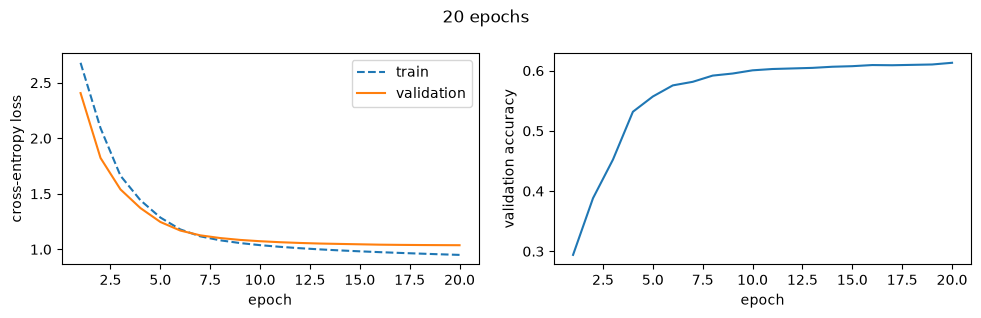

In [13]:
import matplotlib.pyplot as plt

def plot_history(net, title):
    """Validation loss and accuracy per epoch, from the history that skorch keeps during fit."""
    epochs = net.history[:, 'epoch']
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(epochs, net.history[:, 'train_loss'], '--', label='train')
    axes[0].plot(epochs, net.history[:, 'valid_loss'], label='validation')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy loss'); axes[0].legend()
    axes[1].plot(epochs, net.history[:, 'valid_acc'])
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('validation accuracy')
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_history(net, '20 epochs')

Note, you can also use `GridSearchCV` with `skorch` (it follows the `sklearn` API), but be aware that training a neural network takes much more time; a handful of hand-picked configurations, compared on the validation split that `skorch` holds out for you, is enough here.

Play around with 5 different sets of hyperparameters. For example, consider some of the following:

- layer sizes
- activation functions
- regularizers
- early stopping
- vectorizer parameters (`max_features`, `ngram_range`)

Report your best hyperparameter combination.

📝❓ What is the effect of your modifications on validation performance? Discuss potential reasons.

### <span style="color:#1f77b4">HYPERPARAMETER TUNING: SETUP</span>
-  Instead of GridSearchCV, we compare a handful of hand-picked configurations on one fixed validation split (as suggested above). Each configuration changes only one aspect of the baseline, so the effect of every modification can be seen directly.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from skorch.callbacks import EarlyStopping
from skorch.dataset import Dataset
from skorch.helper import predefined_split
import torch.optim as optim

# Fixed train/validation split - the same for every configuration
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train.astype(np.int64), test_size=0.2, stratify=y_train, random_state=seed
)

# Neural network with two hidden layers with optional dropout
class TunableClassifierModule(nn.Module):
    def __init__(self, input_size, num_classes, num_units, num_units2, nonlin, dropout_rate):
        super().__init__()
        self.nonlin = nonlin
        self.drop = nn.Dropout(dropout_rate)
        self.dense0 = nn.Linear(input_size, num_units)
        self.dense1 = nn.Linear(num_units, num_units2)
        self.output = nn.Linear(num_units2, num_classes)

    def forward(self, X, **kwargs):
        X = self.drop(self.nonlin(self.dense0(X)))
        X = self.drop(self.nonlin(self.dense1(X)))
        return self.output(X)   # raw scores, CrossEntropyLoss applies the softmax


def to_dense_float32(X):
    """PyTorch needs a dense float32 array, but TF-IDF returns a sparse matrix."""
    return X.toarray().astype(np.float32)


def train_model(cfg, x_fit, y_fit, x_valid, y_valid):
    """Trains one configuration and returns a pipeline from raw text to predicted label."""
    # TF-IDF of character n-grams, fitted on x_fit only (so x_valid does not leak into the vocabulary)
    vect = TfidfVectorizer(analyzer='char', max_features=cfg['max_features'], ngram_range=cfg['ngram_range'])
    X_fit = to_dense_float32(vect.fit_transform(x_fit))
    X_valid = to_dense_float32(vect.transform(x_valid))

    torch.manual_seed(seed)   # same initial weights for every configuration
    module = TunableClassifierModule(
        X_fit.shape[1], len(label_encoder.classes_),
        cfg['num_units'], cfg['num_units2'], cfg['nonlin'], cfg['dropout_rate'],
    )
    net = NeuralNetClassifier(
        module,
        optimizer=cfg['optimizer'],
        optimizer__weight_decay=cfg['weight_decay'],
        lr=cfg['lr'],
        max_epochs=30,
        batch_size=128,
        criterion=nn.CrossEntropyLoss,
        train_split=predefined_split(Dataset(X_valid, y_valid)),   # validate on our validation set
        # Stop after 3 epochs without improvement and restore the weights of the best epoch
        callbacks=[EarlyStopping(monitor='valid_loss', patience=3, load_best=True)],
        device='cuda' if torch.cuda.is_available() else 'cpu',
        verbose=0,
    )
    net.fit(X_fit, y_fit)
    return Pipeline([('vect', vect), ('todense', FunctionTransformer(to_dense_float32)), ('net', net)])


def run_config(name, cfg):
    """Trains one configuration on the fixed split, plots its history and summarises its best epoch."""
    model = train_model(cfg, x_tr, y_tr, x_val, y_val)
    h = model.named_steps['net'].history
    plot_history(model.named_steps['net'], name)

    best = int(np.argmin(h[:, 'valid_loss']))
    result = {
        'Configuration': name,
        'Valid Acc (%)': 100 * h[best, 'valid_acc'],
        'Valid Loss': h[best, 'valid_loss'],
        'Train Loss': h[best, 'train_loss'],
        'Best Epoch': h[best, 'epoch'],
        'Epochs Run': len(h),
    }
    return result, model

### <span style="color:#1f77b4">HYPERPARAMETER TUNING: FIVE CONFIGURATIONS</span>
- Config 1 is the baseline. Each of the other configurations changes only one aspect of the baseline, so the effect of every modification can be seen directly by comparing it with config 1.

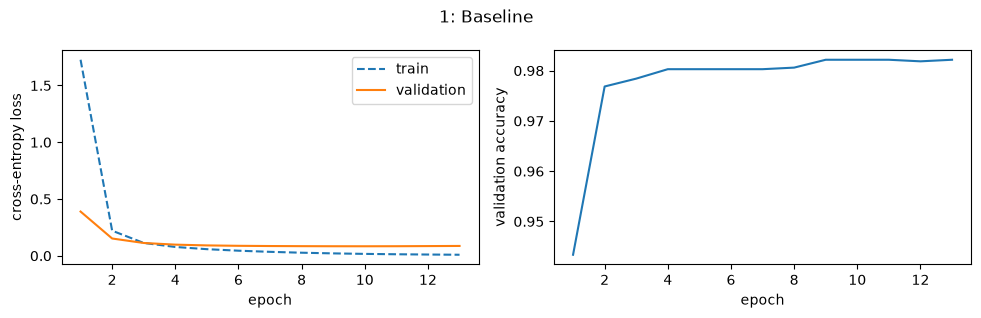

1: Baseline: valid acc 98.22%, best epoch 10


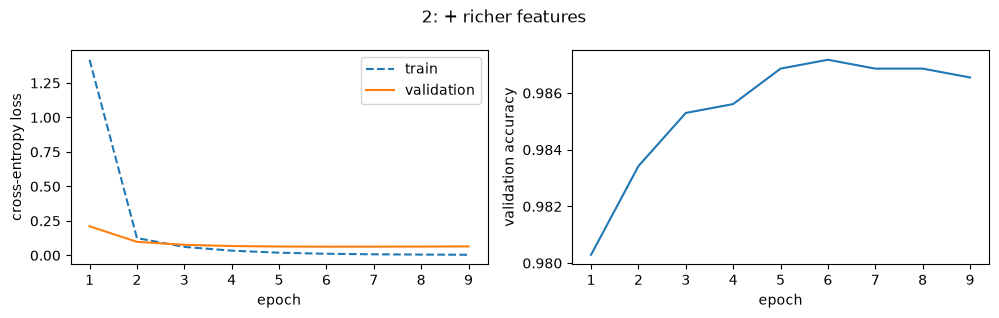

2: + richer features: valid acc 98.72%, best epoch 6


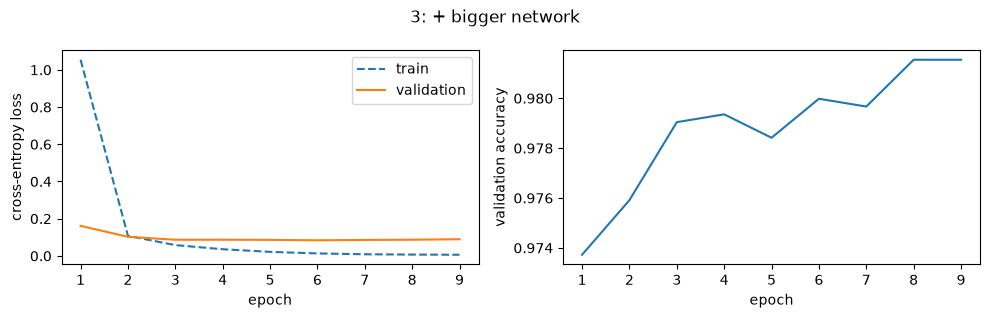

3: + bigger network: valid acc 98.00%, best epoch 6


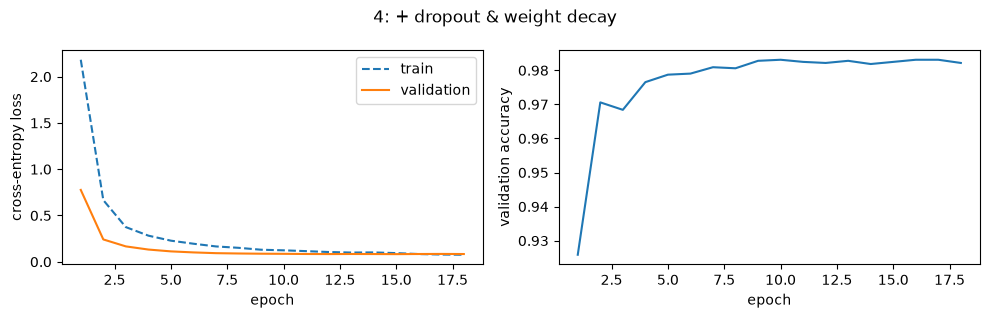

4: + dropout & weight decay: valid acc 98.25%, best epoch 15


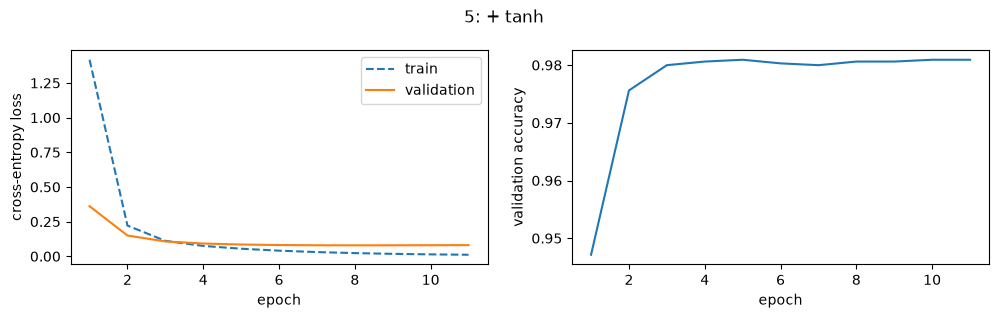

5: + tanh: valid acc 98.06%, best epoch 8


,Configuration,Valid Acc (%),Valid Loss,Train Loss,Best Epoch,Epochs Run,Change vs Baseline (pp)
0,1: Baseline,98.2171,0.0837,0.0166,10,13,0.0000
1,2: + richer features,98.7175,0.0631,0.0114,6,9,0.5005
2,3: + bigger network,97.9981,0.0839,0.0132,6,9,-0.2190
3,4: + dropout & weight decay,98.2484,0.0826,0.0937,15,18,0.0313
4,5: + tanh,98.0607,0.0792,0.0231,8,11,-0.1564


In [15]:
config_1 = dict(
    max_features=2000, ngram_range=(2, 3),     # features
    num_units=200, num_units2=50,              # layer sizes
    nonlin=F.relu,                             # activation function
    dropout_rate=0.0, weight_decay=0.0,        # regularisation
    optimizer=optim.Adam, lr=0.001,            # optimisation
)

configs = {
    '1: Baseline': config_1,
    '2: + richer features': {**config_1, 'max_features': 10000, 'ngram_range': (2, 5)},
    '3: + bigger network': {**config_1, 'num_units': 500, 'num_units2': 200},
    '4: + dropout & weight decay': {**config_1, 'dropout_rate': 0.5, 'weight_decay': 1e-4},
    '5: + tanh': {**config_1, 'nonlin': torch.tanh},
}

results, models = [], {}
for name, cfg in configs.items():
    result, model = run_config(name, cfg)
    results.append(result)
    models[name] = model
    print(f"{name}: valid acc {result['Valid Acc (%)']:.2f}%, best epoch {result['Best Epoch']}")

# Comparison table
results_df = pd.DataFrame(results)
results_df['Change vs Baseline (pp)'] = results_df['Valid Acc (%)'] - results_df.loc[0, 'Valid Acc (%)']
display(results_df.round(4))

### <span style="color:#1f77b4">OVERFITTING CHECK: TRAINING VS. VALIDATION ACCURACY</span>
- skorch only logs the training loss, measured with dropout switched on. Here we evaluate every final model (best-epoch weights, dropout off) on its training and validation data. A large gap between the two accuracies would indicate overfitting.

In [16]:
from sklearn.metrics import accuracy_score

fit_check = pd.DataFrame([
    {
        'Configuration': name,
        'Train Acc (%)': 100 * accuracy_score(y_tr, model.predict(x_tr)),
        'Valid Acc (%)': 100 * accuracy_score(y_val, model.predict(x_val)),
    }
    for name, model in models.items()
])
fit_check['Gap (pp)'] = fit_check['Train Acc (%)'] - fit_check['Valid Acc (%)']
display(fit_check.round(2))

,Configuration,Train Acc (%),Valid Acc (%),Gap (pp)
0,1: Baseline,99.80,98.22,1.58
1,2: + richer features,99.94,98.72,1.22
2,3: + bigger network,99.85,98.00,1.85
3,4: + dropout & weight decay,99.48,98.25,1.24
4,5: + tanh,99.74,98.06,1.68


### <span style="color:#1f77b4">5-FOLD CROSS-VALIDATION OF ALL CONFIGURATIONS</span>
- A single validation split (and a single random seed) can shift the accuracy by ~0.3 pp by chance, which is as large as most differences between our configurations. Cross-validation trains every onfiguration on 5 different train/validation splits of x_train and reports mean ± std. In each fold, the TF-IDF vectorizer is fitted on the training part only, and the test set is not used.
- Note: early stopping uses the held-out fold, which makes the scores slightly optimistic; the bias is the same for every configuration, so the comparison stays fair.

1: Baseline: 98.09 ± 0.12%
2: + richer features: 98.52 ± 0.08%
3: + bigger network: 98.02 ± 0.18%
4: + dropout & weight decay: 98.20 ± 0.12%
5: + tanh: 98.14 ± 0.15%


,Configuration,CV Valid Acc (%),Std (pp),CV Train Acc (%),Gap (pp),Mean Best Epoch,Change vs Baseline (pp)
0,2: + richer features,98.517,0.079,99.897,1.380,6.2,0.425
1,4: + dropout & weight decay,98.198,0.124,99.493,1.295,15.8,0.106
2,5: + tanh,98.142,0.148,99.758,1.616,7.8,0.050
3,1: Baseline,98.092,0.123,99.628,1.536,8.0,0.000
4,3: + bigger network,98.023,0.177,99.665,1.642,4.4,-0.069


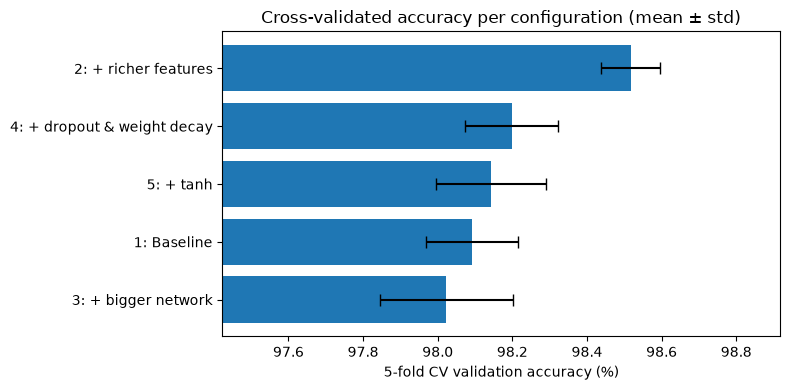

In [17]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
folds = list(skf.split(x_train, y_train))

def cross_validate_config(cfg):
    fold_rows = []
    for tr_idx, va_idx in folds:
        x_f_tr, x_f_va = x_train.iloc[tr_idx], x_train.iloc[va_idx]
        y_f_tr, y_f_va = y_train[tr_idx].astype(np.int64), y_train[va_idx].astype(np.int64)

        model = train_model(cfg, x_f_tr, y_f_tr, x_f_va, y_f_va)

        h = model.named_steps['net'].history
        fold_rows.append({
            'train_acc': 100 * accuracy_score(y_f_tr, model.predict(x_f_tr)),
            'valid_acc': 100 * accuracy_score(y_f_va, model.predict(x_f_va)),
            'best_epoch': h[int(np.argmin(h[:, 'valid_loss'])), 'epoch'],
        })
    return pd.DataFrame(fold_rows)

cv_folds = {}
for name, cfg in configs.items():
    cv_folds[name] = cross_validate_config(cfg)
    print(f"{name}: {cv_folds[name]['valid_acc'].mean():.2f} ± {cv_folds[name]['valid_acc'].std():.2f}%")

# Summary table: mean and standard deviation over the 5 folds
cv_summary = pd.DataFrame([
    {
        'Configuration': name,
        'CV Valid Acc (%)': f['valid_acc'].mean(),
        'Std (pp)': f['valid_acc'].std(),
        'CV Train Acc (%)': f['train_acc'].mean(),
        'Gap (pp)': f['train_acc'].mean() - f['valid_acc'].mean(),
        'Mean Best Epoch': f['best_epoch'].mean(),
    }
    for name, f in cv_folds.items()
])
cv_summary['Change vs Baseline (pp)'] = (
    cv_summary['CV Valid Acc (%)']
    - cv_summary.loc[cv_summary['Configuration'] == '1: Baseline', 'CV Valid Acc (%)'].item()
)
cv_summary = cv_summary.sort_values('CV Valid Acc (%)', ascending=False).reset_index(drop=True)
display(cv_summary.round(3))

# Bar chart with the standard deviation over the folds as error bars
plot_df = cv_summary.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_df['Configuration'], plot_df['CV Valid Acc (%)'], xerr=plot_df['Std (pp)'], capsize=4)
ax.set_xlim(plot_df['CV Valid Acc (%)'].min() - 0.6, plot_df['CV Valid Acc (%)'].max() + 0.4)
ax.set_xlabel(f'{n_splits}-fold CV validation accuracy (%)')
ax.set_title('Cross-validated accuracy per configuration (mean ± std)')
plt.tight_layout(); plt.show()

☝ Note, during model development, if you run into the infamous CUDA out-of-memory (OOM) error, try clearing the GPU memory either with `torch.cuda.empty_cache()` or restarting the runtime.

### <span style="color:#1f77b4">BEST MODEL</span>
- The best configuration is chosen by its cross-validated accuracy (the test set is not used). Its model from the fixed split is already trained (with the weights of its best epoch, thanks to load_best=True, so it does not need retraining.

In [18]:
best_name = cv_summary.loc[0, 'Configuration']
best_model = models[best_name]

print('Best configuration:', best_name)
for k, v in configs[best_name].items():
    print(f'  {k}: {getattr(v, "__name__", v)}')

Best configuration: 2: + richer features
  max_features: 10000
  ngram_range: (2, 5)
  num_units: 200
  num_units2: 50
  nonlin: relu
  dropout_rate: 0.0
  weight_decay: 0.0
  optimizer: Adam
  lr: 0.001


In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#PREDICT ON TEST SET
y_pred = best_model.predict(x_test)

#TEST ACCURACY
print("TEST SET RESULTS")
print(
    f"\nTest Accuracy: "
    f"{accuracy_score(y_test, y_pred):.3f}"
)

TEST SET RESULTS

Test Accuracy: 0.985


In [20]:
#CLASSIFICATION REPORT
target_names = label_encoder.classes_
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names,
        digits=3,
        zero_division=0
    )
)


Classification Report:

              precision    recall  f1-score   support

         ara      1.000     1.000     1.000       200
         asm      0.985     0.975     0.980       200
         dan      0.985     0.970     0.977       200
         deu      0.985     0.995     0.990       200
         eng      0.883     0.985     0.931       200
         fra      0.985     0.990     0.987       198
         heb      1.000     0.995     0.997       200
         hin      0.995     0.975     0.985       200
         ita      0.980     0.995     0.988       200
         jpn      1.000     0.960     0.980       200
         kan      1.000     0.995     0.997       200
         kor      1.000     0.980     0.990       200
         nld      1.000     0.990     0.995       200
         nob      0.995     0.980     0.987       200
         rus      1.000     0.980     0.990       200
         spa      0.995     0.985     0.990       199
         swe      1.000     0.995     0.997       199
  

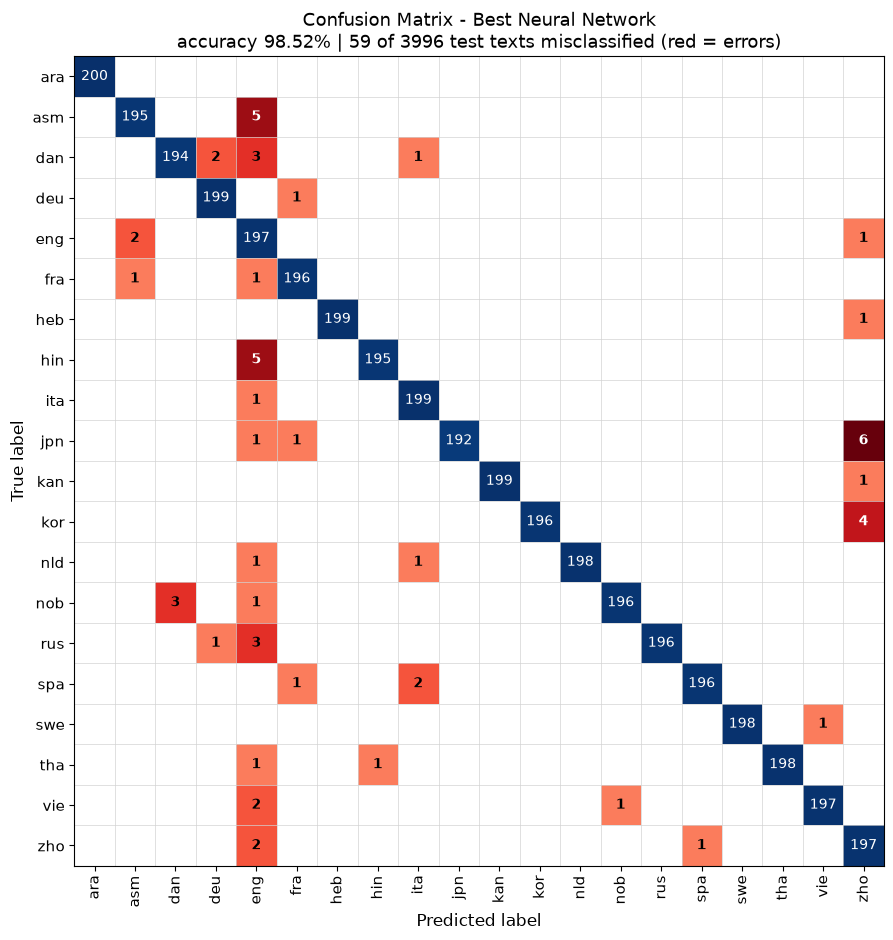

In [21]:
# CONFUSION MATRIX
#   - correct predictions (diagonal) in blue, errors (off-diagonal) in red
#   - zeros are left empty, so only the cells that matter show a number
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_
    n = len(labels)
    on_diagonal = np.eye(n, dtype=bool)

    correct = np.where(on_diagonal, cm, np.nan)
    errors = np.where(~on_diagonal & (cm > 0), cm, np.nan)
    max_error = max(cm[~on_diagonal].max(), 1)

    fig, ax = plt.subplots(figsize=(11, 9.5))
    ax.imshow(correct, cmap='Blues', vmin=0, vmax=cm.max())
    ax.imshow(errors, cmap='Reds', vmin=-max_error / 2, vmax=max_error)

    for i in range(n):
        for j in range(n):
            if cm[i, j] > 0:
                dark_cell = i == j or cm[i, j] > 0.6 * max_error
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=10,
                        color='white' if dark_cell else 'black',
                        fontweight='normal' if i == j else 'bold')

    ax.set_xticks(np.arange(n + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='lightgrey', linewidth=0.5)
    ax.tick_params(which='minor', length=0)

    ax.set_xticks(range(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(range(n), labels, fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.set_ylabel('True label', fontsize=12)

    n_errors = int(cm.sum() - np.trace(cm))
    ax.set_title(f"{title}\naccuracy {accuracy_score(y_true, y_pred):.2%} | "
                 f"{n_errors} of {cm.sum()} test texts misclassified (red = errors)", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, y_pred, "Confusion Matrix - Best Neural Network")

In [22]:
#TRAINING HISTORY OF THE BEST MODEL
net = best_model.named_steps['net']
h = net.history
best = int(np.argmin(h[:, 'valid_loss']))

print("Epochs trained:", len(h))
print("Best epoch (weights restored):", h[best, 'epoch'])
print(f"Best validation loss: {h[best, 'valid_loss']:.4f}")
print(f"Train loss at that epoch: {h[best, 'train_loss']:.4f}")

Epochs trained: 9
Best epoch (weights restored): 6
Best validation loss: 0.0631
Train loss at that epoch: 0.0114


### <span style="color:#1f77b4">ERROR ANALYSIS: WHY DOES THE MODEL MAKE THESE MISTAKES?</span>
This analysis explains the errors of the best model on the **validation set** (`x_val`); it motivates the feature change in the next section. The test set is not used here, so it stays unseen until the final comparison to avoid data leak.
- (a) How many features (vocabulary n-grams) does each writing system get?
- (b) What share of a text's n-grams can the model actually "see", per language?
- (c) What do the misclassified texts look like?

In [23]:
import unicodedata
from collections import Counter

SCRIPTS = ['LATIN', 'CYRILLIC', 'ARABIC', 'HEBREW', 'DEVANAGARI', 'BENGALI', 'KANNADA',
           'THAI', 'HANGUL', 'HIRAGANA', 'KATAKANA', 'CJK']

def char_script(ch):
    """Writing system of a character, read from its Unicode name ('LATIN SMALL LETTER A' -> 'LATIN').
    Digits, punctuation, spaces etc. are 'OTHER'. 'CJK' = Chinese characters (also used in Japanese)."""
    name = unicodedata.name(ch, '')
    return next((s for s in SCRIPTS if name.startswith(s)), 'OTHER')

def script_mix(text):
    """The three most frequent writing systems in a text, with their share of the characters."""
    counts = Counter(char_script(c) for c in text if not c.isspace())
    total = sum(counts.values())
    return ', '.join(f'{s} {100 * n / total:.0f}%' for s, n in counts.most_common(3))

# Everything below uses the validation split and the test set is not looked at
y_val_pred = best_model.predict(x_val)
val_languages = label_encoder.inverse_transform(y_val)

vect = best_model.named_steps['vect']
vocab = vect.get_feature_names_out()

# (a) max_features keeps the most frequent n-grams over ALL languages together.
#     Languages that share an alphabet (Latin) produce many frequent n-grams; languages with
#     thousands of different characters (Chinese, Japanese, Korean) produce few.
vocab_per_script = Counter(
    script for gram in vocab for script in {char_script(c) for c in gram} - {'OTHER'}
)
print(f"(a) Number of the {len(vocab)} vocabulary n-grams that contain each writing system:")
display(pd.DataFrame(vocab_per_script.most_common(), columns=['Writing system', 'Vocabulary n-grams']))

# (b) Coverage: the share of a text's n-grams that are in the vocabulary.
analyzer = vect.build_analyzer()
vocab_set = set(vocab)

def coverage(text):
    grams = analyzer(text)
    return sum(g in vocab_set for g in grams) / max(len(grams), 1)

coverage_df = (
    pd.DataFrame({'Language': val_languages, 'Coverage (%)': [100 * coverage(t) for t in x_val]})
    .groupby('Language')['Coverage (%)'].mean()
    .sort_values()
    .round(1)
    .to_frame()
)
print("\n(b) Average share of a validation text's n-grams that are in the vocabulary:")
display(coverage_df)

# (c) The most frequent confusions with examples of the misclassified texts
errors = pd.DataFrame({
    'True': val_languages,
    'Predicted': label_encoder.inverse_transform(y_val_pred),
    'Text': x_val.values,
})
errors = errors[errors['True'] != errors['Predicted']]
errors['Writing systems'] = errors['Text'].apply(script_mix)
errors['Text'] = errors['Text'].str[:100] + '...'

top_confusions = errors.groupby(['True', 'Predicted']).size().sort_values(ascending=False)
print(f"\n(c) {len(errors)} of {len(y_val)} validation texts are misclassified. Most frequent confusions:")
display(top_confusions.head(10).to_frame('Count'))

print("Examples of the 5 most frequent confusions (first 100 characters):")
with pd.option_context('display.max_colwidth', 110):
    for (true, pred) in top_confusions.index[:5]:
        examples = errors[(errors['True'] == true) & (errors['Predicted'] == pred)].head(3)
        display(examples[['True', 'Predicted', 'Writing systems', 'Text']])

(a) Number of the 10000 vocabulary n-grams that contain each writing system:


,Writing system,Vocabulary n-grams
0,LATIN,5980
1,DEVANAGARI,656
2,KANNADA,581
3,CYRILLIC,530
4,ARABIC,527
5,HEBREW,466
6,BENGALI,442
7,THAI,397
8,HANGUL,112
9,HIRAGANA,44



(b) Average share of a validation text's n-grams that are in the vocabulary:


,Coverage (%)
Language,
zho,4.5
jpn,5.8
kor,10.4
tha,21.5
asm,28.4
heb,30.2
kan,31.8
rus,32.2
ara,32.6



(c) 41 of 3197 validation texts are misclassified. Most frequent confusions:


,,Count
True,Predicted,
nob,dan,5
jpn,zho,4
asm,eng,3
dan,deu,3
zho,eng,2
hin,eng,2
dan,fra,1
rus,spa,1
zho,deu,1


Examples of the 5 most frequent confusions (first 100 characters):


,True,Predicted,Writing systems,Text
429,nob,dan,"LATIN 89%, OTHER 11%","CR-V fåes med bensinmotor på 2 liter med 155 HK og AWD, manuell og automatgir, 2,2 liter diesel på 1..."
720,nob,dan,"LATIN 92%, OTHER 8%","Mathilde Juncker (født 3. mars 1993 i Roskilde) er en dansk håndballspiller, som spiller for den dan..."
909,nob,dan,"LATIN 90%, OTHER 10%","MF «Etne», tidligere «Askøy», er en bilferge bygget i 1979 for Rutelaget Askøy-Bergen. Fergen går i ..."


,True,Predicted,Writing systems,Text
1182,jpn,zho,"CJK 67%, OTHER 13%, HIRAGANA 13%",1974年の第10回参議院議員通常選挙で全国区に出馬し初当選。沖縄開発政務次官を務める。1979年の第35回衆議院議員総選挙にて、旧山口2区へ出馬し衆議院議員に初当選（当選同期に保利耕輔・畑英次郎・麻...
1336,jpn,zho,"OTHER 52%, CJK 30%, HIRAGANA 9%",2016年終了時点での試合出場数は1860試合。オールスターゲーム出場3回（2001年、2004年、2011年。内2001年の第2戦と2011年の第2戦で球審）、日本シリーズ出場5回（2006年、20...
2996,jpn,zho,"LATIN 36%, CJK 23%, HIRAGANA 20%",2014年11月27日、Mac App Store 版 Jedit Xの公開を中止。Mac App Store側のレギュレーション変更に伴い、Jedit Xに大幅な書き直しが求められたため。Web版は...


,True,Predicted,Writing systems,Text
731,asm,eng,"LATIN 86%, OTHER 14%","Schetini de Azevedo, Cristiano; Penha Tinoco, Herlandes; Bosco Ferraz, João & Young, Robert John (20..."
979,asm,eng,"LATIN 97%, OTHER 3%","Even where it is not native, some indigenous herbivores are liable to utilize lebbeck as a food reso..."
1383,asm,eng,"LATIN 94%, OTHER 6%","Female : Tailless. Above, the butterfly is grey-brown. It has dark stripes in between the veins. It ..."


,True,Predicted,Writing systems,Text
824,dan,deu,"LATIN 88%, OTHER 12%",Ralph-Johannes Lilie: Handel und Politik zwischen dem Byzantinischen Reich und den italienischen Kom...
2007,dan,deu,"LATIN 76%, OTHER 24%",J. Jegerlehner: Der Aufstand der kandiotischen Ritterschaft gegen das Mutterland Venedig (1363–1365)...
2744,dan,deu,"LATIN 84%, OTHER 16%",Ludo (Ludwig) Moritz Hartmann: Die wirtschaftlichen Anfänge Venedigs. I: Vierteljahrschrift für Wirt...


,True,Predicted,Writing systems,Text
1886,zho,eng,"LATIN 87%, OTHER 13%","International economics (London: Nisbet, and Cambridge: Cambridge University Press; New York: Harcou..."
2092,zho,eng,"CJK 65%, LATIN 23%, OTHER 12%","她和 Gut 唱片公司簽約，公司準備為她錄製專輯，但發佈前公司倒閉了。後來她發現作為一位作曲家比較創佳績，獲得了索尼 ATV 的出版合同。她與麥莉·希拉的 ""Party in the USA"" 的制片..."


### <span style="color:#1f77b4">Why does `ngram_range=(2, 5)` fail for Chinese, Japanese and Korean?</span>

The error analysis above shows three kinds of remaining errors:

1. **Label noise:** Some texts carry the label of the Wikipedia they come from, but are written in another language, e.g. English references labelled `asm` or `hin`, or Classical Chinese labelled `kor`. The model cannot (and should not) get these "right", which is why 100% accuracy is not a realistic goal.
2. **Closely related languages:** Written Norwegian Bokmål (`nob`) is very similar to Danish (`dan`).
3. **Too few features for Chinese, Japanese and Korean:** `max_features` keeps the most frequent n-grams over *all* languages together. The Latin-script languages share one alphabet, so their n-grams are frequent and fill most of the vocabulary (table (a)). Chinese and Japanese use thousands of different characters, so any particular combination of 2–5 characters is rare and hardly makes it into the vocabulary. The model therefore sees only a small share of the n-grams of a Chinese, Japanese or Korean text (table (b)), and a Japanese text with many Chinese characters (kanji) looks like a Chinese one.

**The Fix:** Also use single characters, i.e. `ngram_range=(1, 5)`. Single characters are frequent even in Chinese and Japanese, and a single kana character (hiragana/katakana) already shows that a text is Japanese and not Chinese. Below, we retrain the best configuration with only this change and compare it with the original model.

*Note:* this change was motivated by the error analysis on the **validation** set, and the decision is based on validation results only. The test set was not used for the analysis or the decision, so its score below is an unbiased final check.

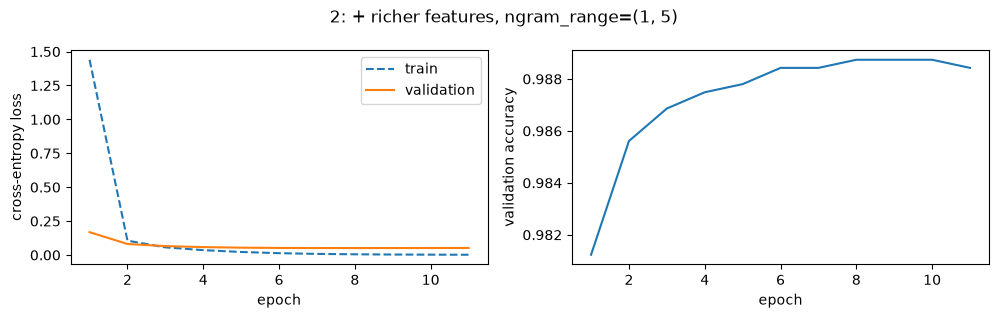

Features,"ngram_range=(2, 5)","ngram_range=(1, 5)"
Valid Acc (%),98.72,98.87
Misclassified validation texts,41.00,36.00
jpn predicted as zho,4.00,1.00
kor predicted as zho,1.00,0.00
Coverage zho (%),4.50,15.06
Coverage jpn (%),5.84,19.85
Coverage kor (%),10.37,24.26
Test Acc (%),98.52,98.87


In [24]:
# BEST CONFIGURATION WITH SINGLE CHARACTERS: ngram_range=(1, 5)
# Same configuration as the best model, only the n-gram range now starts at 1.
best_cfg = configs[best_name]
improved_cfg = {**best_cfg, 'ngram_range': (1, best_cfg['ngram_range'][1])}

improved_result, improved_model = run_config(f"{best_name}, ngram_range={improved_cfg['ngram_range']}", improved_cfg)
y_val_pred_improved = improved_model.predict(x_val)
y_pred_improved = improved_model.predict(x_test)   # only for the final test score


def language_coverage(model, language):
    """Average share of the n-grams of a language's validation texts that are in the model's vocabulary."""
    vect = model.named_steps['vect']
    vocab, analyzer = set(vect.get_feature_names_out()), vect.build_analyzer()
    shares = []
    for text in x_val[val_languages == language]:
        grams = analyzer(text)
        shares.append(sum(g in vocab for g in grams) / max(len(grams), 1))
    return 100 * np.mean(shares)


# Compare the original and the improved model: analysis on the validation set, test accuracy as final check
old_result = next(r for r in results if r['Configuration'] == best_name)
idx = {lang: i for i, lang in enumerate(label_encoder.classes_)}

rows = []
for result, model, val_pred, test_pred in [
    (old_result, best_model, y_val_pred, y_pred),
    (improved_result, improved_model, y_val_pred_improved, y_pred_improved),
]:
    cm_model = confusion_matrix(y_val, val_pred)
    rows.append({
        'Features': f"ngram_range={model.named_steps['vect'].ngram_range}",
        'Valid Acc (%)': result['Valid Acc (%)'],
        'Misclassified validation texts': int((val_pred != y_val).sum()),
        'jpn predicted as zho': cm_model[idx['jpn'], idx['zho']],
        'kor predicted as zho': cm_model[idx['kor'], idx['zho']],
        'Coverage zho (%)': language_coverage(model, 'zho'),
        'Coverage jpn (%)': language_coverage(model, 'jpn'),
        'Coverage kor (%)': language_coverage(model, 'kor'),
        'Test Acc (%)': 100 * accuracy_score(y_test, test_pred),
    })

comparison = pd.DataFrame(rows).set_index('Features').T
display(comparison.round(2))

Classification Report (ngram_range=(1,5)):

              precision    recall  f1-score   support

         ara      1.000     1.000     1.000       200
         asm      0.990     0.975     0.982       200
         dan      0.980     0.970     0.975       200
         deu      0.975     0.995     0.985       200
         eng      0.896     0.990     0.941       200
         fra      0.990     0.990     0.990       198
         heb      1.000     0.995     0.997       200
         hin      0.995     0.975     0.985       200
         ita      0.975     0.995     0.985       200
         jpn      1.000     0.990     0.995       200
         kan      1.000     1.000     1.000       200
         kor      1.000     1.000     1.000       200
         nld      1.000     0.990     0.995       200
         nob      0.995     0.975     0.985       200
         rus      1.000     0.980     0.990       200
         spa      1.000     0.985     0.992       199
         swe      1.000     0.995    

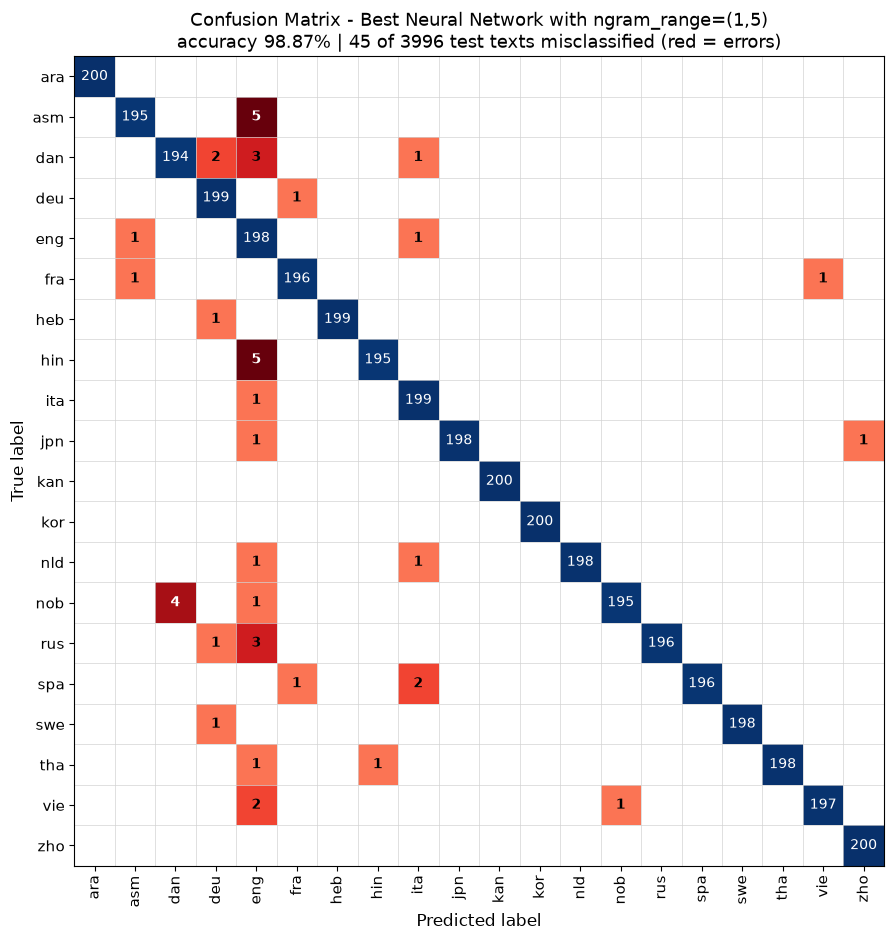

In [25]:
#CLASSIFICATION REPORT AND CONFUSION MATRIX OF THE IMPROVED MODEL
print("Classification Report (ngram_range=(1,5)):\n")
print(
    classification_report(
        y_test,
        y_pred_improved,
        target_names=target_names,
        digits=3,
        zero_division=0
    )
)

plot_confusion_matrix(y_test, y_pred_improved, "Confusion Matrix - Best Neural Network with ngram_range=(1,5)")


---

## Lab report

📝❓ Write your lab report here, addressing all questions in the notebook. For convenience, the questions are collected below; please keep your answers clearly marked.

### Questions

- 📝❓ Report your best hyperparameter combination.

| <span style="color:#1f77b4">Hyperparameter</span> | <span style="color:#1f77b4">Our final best model (config 2 + single characters)</span> |
|---|---|
| Vectorizer | TF-IDF, character n-grams |
| `ngram_range` | (1, 5) |
| `max_features` | 10000 |
| Hidden layers (units) | 200, 50 |
| Activation function | ReLU |
| Dropout | 0.0 |
| Weight decay | 0.0 |
| Optimizer | Adam |
| Learning rate | 0.001 |
| Batch size | 128 |
| Max epochs | 30 (early stopping on validation loss, patience 3, best weights restored) |
| Best epoch | see notebook output |
| Validation accuracy | 98.87% |
| Test accuracy | 98.87% |



- 📝❓ What is the effect of your modifications on validation performance? Discuss potential reasons.



We started from a baseline (config 1) and made four modifications. Each one changes **only one thing**, so any difference in validation accuracy can be attributed to that change.

| <span style="color:#1f77b4">Configuration</span> | <span style="color:#1f77b4">What we changed</span> | <span style="color:#1f77b4">Validation accuracy (%)</span> | <span style="color:#1f77b4">Change vs. baseline (pp)</span> | <span style="color:#1f77b4">CV validation accuracy (%)</span> | <span style="color:#1f77b4">Change vs. baseline, CV (pp)</span> |
|---|---|---|---|---|---|
| 1: Baseline | – (2000 features, 2–3-grams, 200/50 units, ReLU, no regularisation) | 98.22 | – | 98.09 ± 0.12 | – |
| 2: Richer features | 10000 features, 2–5-grams | **98.72** | **+0.50** | **98.52 ± 0.08** | **+0.43** |
| 3: Bigger network | 500/200 hidden units | 98.00 | −0.22 | 98.02 ± 0.18 | −0.07 |
| 4: Regularisation | dropout 0.5, weight decay 1e-4 | 98.25 | +0.03 | 98.20 ± 0.12 | +0.11 |
| 5: Activation | tanh instead of ReLU | 98.06 | −0.16 | 98.14 ± 0.15 | +0.05 |

**How to read the table:** *Validation accuracy* is measured on our fixed validation split (20% of the training data). Because the differences are small, we also ran 5-fold cross-validation (*CV validation accuracy*): every configuration is trained and evaluated on 5 different splits, and we report the mean ± standard deviation. A change is only meaningful if it is clearly larger than this standard deviation (about 0.1–0.2 pp). By this standard, only richer features improve validation accuracy; the other changes are within random variation.

**Effect of each modification and potential reasons:**

- **Richer features: clear improvement (+0.50 pp, CV +0.43 pp).** The model identifies languages from character patterns. The baseline uses only 2000 short n-grams (2–3 characters) for 20 languages, so many patterns that distinguish languages are missing. With 10000 features and n-grams of up to 5 characters, the model also sees short words and word pieces typical of one language (e.g. " und " for German, " och " for Swedish, "ijk" for Dutch). This model also has the lowest validation loss (0.063 vs. 0.084 for the baseline) and reaches its best epoch faster (epoch 6 vs. 10).

- **Bigger network: no improvement (−0.22 pp, CV −0.07 pp).** All models already classify 99.5–99.9% of the training data correctly, so the baseline network is big enough. The extra units only make the model fit the training data more closely: the gap between training and validation accuracy grows from 1.58 to 1.85 pp.

- **Dropout and weight decay: no clear improvement (+0.03 pp, CV +0.11 pp).** Regularisation reduces overfitting: the gap between training and validation accuracy shrinks from 1.58 to 1.24 pp. However, validation accuracy hardly changes, and training needs more epochs (best epoch 15 vs. 10). Overfitting is therefore not what limits the model.

- **tanh instead of ReLU: no clear effect (−0.16 pp, CV +0.05 pp).** The two measurements even point in opposite directions, which shows the difference is just random variation. For a small network with two hidden layers, the choice of activation function hardly matters.

**Conclusion:** changing the network (size, regularisation, activation function) has no clear effect on validation accuracy, while better input features clearly improve it. The model is therefore limited by **what information it receives**, not by how it learns. The remaining errors confirm this: they come from label noise (e.g. English texts labelled `asm` or `hin`), closely related languages (`nob`/`dan`), and too few features for Chinese, Japanese and Korean. Adding single characters (`ngram_range=(1, 5)`) improves the coverage of these three languages and raises validation accuracy further, from 98.72% to 98.87%. We also tested the combinations of the changes (e.g. richer features with bigger network etc.) but the results were very similar, so they are not reported here.



## Declarations

Please fill in both declarations below by editing this cell (double-click it). Mark the applicable option by replacing ☐ with ☒ (copy the symbol from here: ☒) and complete the text field where required. Your reviewers will check that both declarations are present and completed.

### Contribution declaration

By submitting this work, the group declares that the contributions of the group members were:

☒ approximately equal

☐ not approximately equal

If the contributions were not approximately equal, no individual group member needs to be identified.

### Declaration on the use of AI

The group declares that any use of AI-based tools in preparing this work complied with the rules specified for this exercise.

☐ No AI-based tools were used.

☒ AI-based tools were used in accordance with the rules of the exercise.

If AI-based tools were used, briefly state the tool(s) used and the purpose(s) for which they were used:
- Claude Opus 5.5 is used for debugging and simplifying code, for graphs, shaping markdown texts (tables, colors etc.), and for understanding certain results. 

